============================================================
# CELL 1: SETUP ENVIRONMENT
============================================================

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os
import urllib.request

# Cek device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seed untuk reproduksibilitas
torch.manual_seed(42)
np.random.seed(42)

print("✅ Environment setup complete!")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
✅ Environment setup complete!
PyTorch version: 2.11.0+cpu


============================================================
# CELL 2: LOAD DATASET MNIST
============================================================

📁 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📂 Checking dataset paths...
   Training path: /content/drive/MyDrive/dataset/MNIST/training
   Testing path: /content/drive/MyDrive/dataset/MNIST/testing
✅ Dataset folders found!

CELL 2: LOAD CUSTOM DATASET FROM GOOGLE DRIVE

📥 Loading dataset from: /content/drive/MyDrive/dataset/MNIST/training
   Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
   Class 0: 5933 images
   Class 1: 6752 images
   Class 2: 5958 images
   Class 3: 6141 images
   Class 4: 5842 images
   Class 5: 5441 images
   Class 6: 5928 images
   Class 7: 6285 images
   Class 8: 5851 images
   Class 9: 5959 images
   Total images loaded: 60090

📥 Loading dataset from: /content/drive/MyDrive/dataset/MNIST/testing
   Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
   Class 0: 980 images
   Class 1: 1135 images
   Class 2: 1032 imag

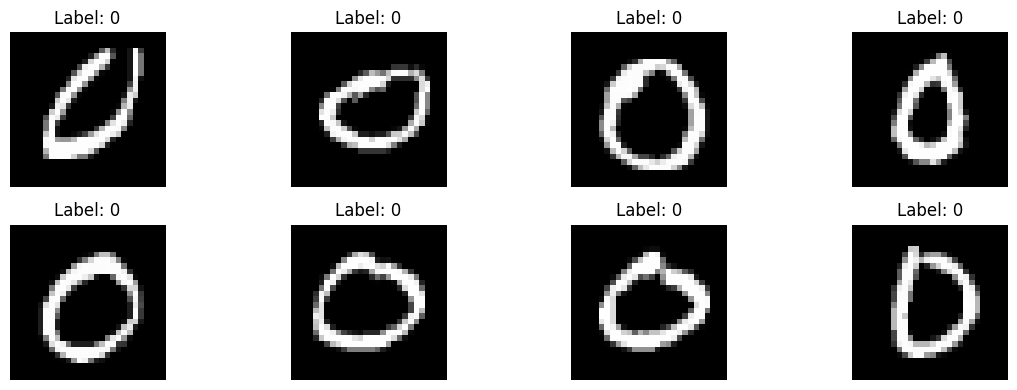


📊 Dataset Information:
   Training classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
   Testing classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
   Image size: 28x28 pixels (grayscale)

✅ CELL 2 COMPLETED!


In [19]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
print("📁 Mounting Google Drive...")
drive.mount('/content/drive')

# ============================================================
# 1. Tentukan Path ke Dataset di Drive
# ============================================================

# Ganti path ini sesuai dengan lokasi folder dataset Anda di Drive
# Contoh: '/content/drive/MyDrive/Colab_Projects/handwritten_dataset/'
DATASET_PATH = '/content/drive/MyDrive/dataset/MNIST/'  # ← SESUAIKAN!

TRAIN_PATH = os.path.join(DATASET_PATH, 'training')
TEST_PATH = os.path.join(DATASET_PATH, 'testing')

# Cek apakah folder ada
print(f"\n📂 Checking dataset paths...")
print(f"   Training path: {TRAIN_PATH}")
print(f"   Testing path: {TEST_PATH}")

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"❌ Training folder tidak ditemukan di: {TRAIN_PATH}")
if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"❌ Testing folder tidak ditemukan di: {TEST_PATH}")

print("✅ Dataset folders found!")

# ============================================================
# 2. Custom Dataset Class
# ============================================================

class HandwrittenDigitDataset(Dataset):
    """
    Dataset untuk gambar tulisan tangan angka 0-9
    Struktur folder:
        training/
            0/
                img1.png
                img2.png
            ...
            9/
                img1.png
        testing/
            0/
                ...
            9/
                ...
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: int(cls) for cls in self.classes}  # Angka 0-9

        self.images = []
        self.labels = []

        print(f"\n📥 Loading dataset from: {root_dir}")
        print(f"   Classes found: {self.classes}")

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            class_label = self.class_to_idx[class_name]

            # Cari semua file gambar di folder kelas
            image_files = [f for f in os.listdir(class_dir)
                          if f.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

            for img_file in image_files:
                self.images.append(os.path.join(class_dir, img_file))
                self.labels.append(class_label)

            print(f"   Class {class_name}: {len(image_files)} images")

        print(f"   Total images loaded: {len(self.images)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        # Load image dengan PIL
        image = Image.open(img_path).convert('L')  # Grayscale

        # Resize ke 28x28 (standar MNIST) jika perlu
        if image.size != (28, 28):
            image = image.resize((28, 28), Image.Resampling.LANCZOS)

        # Apply transformasi
        if self.transform:
            image = self.transform(image)

        return image, label

# ============================================================
# 3. Fungsi Load Dataset
# ============================================================

def load_custom_dataset(batch_size=128, num_train_samples=None, num_test_samples=None):
    """
    Load dataset dari Google Drive

    Args:
        batch_size: Ukuran batch
        num_train_samples: Jumlah sampel training (None = semua)
        num_test_samples: Jumlah sampel testing (None = semua)
    """
    # Transformasi untuk data
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalisasi ke [-1, 1]
    ])

    # Load dataset
    train_dataset = HandwrittenDigitDataset(TRAIN_PATH, transform=transform)
    test_dataset = HandwrittenDigitDataset(TEST_PATH, transform=transform)

    # Ambil subset jika diperlukan
    if num_train_samples and num_train_samples < len(train_dataset):
        indices = torch.randperm(len(train_dataset))[:num_train_samples]
        train_dataset = torch.utils.data.Subset(train_dataset, indices)
        print(f"   Using subset of training: {len(train_dataset)} samples")

    if num_test_samples and num_test_samples < len(test_dataset):
        indices = torch.randperm(len(test_dataset))[:num_test_samples]
        test_dataset = torch.utils.data.Subset(test_dataset, indices)
        print(f"   Using subset of testing: {len(test_dataset)} samples")

    # Buat DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(f"\n✅ Dataset loaded!")
    print(f"   Training samples: {len(train_dataset)}")
    print(f"   Testing samples: {len(test_dataset)}")

    return train_loader, test_loader, train_dataset, test_dataset

# ============================================================
# 4. EKSEKUSI
# ============================================================

print("\n" + "="*50)
print("CELL 2: LOAD CUSTOM DATASET FROM GOOGLE DRIVE")
print("="*50)

# Load dataset
train_loader, test_loader, train_dataset, test_dataset = load_custom_dataset(
    batch_size=128,
    num_train_samples=None,  # Gunakan semua data training
    num_test_samples=None     # Gunakan semua data testing
)

# ============================================================
# 5. VISUALISASI SAMPLE
# ============================================================

def show_samples(loader, num_samples=8):
    """
    Menampilkan sample gambar dari dataset
    """
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 4))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i+1)
        # Denormalize dari [-1,1] ke [0,1] untuk ditampilkan
        img = images[i].squeeze().numpy()
        img = (img + 1) / 2  # Kembali ke rentang [0,1]
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Cek sample pertama
print("\n🖼️ Sample images from dataset:")
show_samples(test_loader, num_samples=8)

# ============================================================
# 6. INFORMASI DATASET
# ============================================================

print("\n📊 Dataset Information:")
print(f"   Training classes: {train_dataset.classes if hasattr(train_dataset, 'classes') else 'N/A'}")
print(f"   Testing classes: {test_dataset.classes if hasattr(test_dataset, 'classes') else 'N/A'}")
print(f"   Image size: 28x28 pixels (grayscale)")

print("\n✅ CELL 2 COMPLETED!")

============================================================
# CELL 3: DEFINISI MODEL SIMPLECNN
============================================================

In [20]:
class SimpleCNN(nn.Module):
    """
    Model CNN sederhana untuk klasifikasi MNIST
    Arsitektur:
    - Conv2d(1, 32, 3, 1) -> ReLU -> MaxPool(2,2)
    - Conv2d(32, 64, 3, 1) -> ReLU -> MaxPool(2,2)
    - Dropout(0.25)
    - Flatten
    - Linear(64*7*7, 128) -> ReLU -> Dropout(0.5)
    - Linear(128, 10)
    """
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        # 28x28 -> 14x14 -> 7x7 setelah 2x pooling
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout1(x)
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

def create_model():
    """
    Membuat instance model SimpleCNN
    """
    model = SimpleCNN()
    model = model.to(device)
    print(f"✅ Model created!")
    print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    return model

# Eksekusi
print("\n" + "="*50)
print("CELL 3: DEFINISI MODEL SIMPLECNN")
print("="*50)

model = create_model()

# Tampilkan arsitektur
print("\n📋 Model Architecture:")
print(model)

print("\n✅ CELL 3 COMPLETED!")


CELL 3: DEFINISI MODEL SIMPLECNN
✅ Model created!
   Total parameters: 421,834

📋 Model Architecture:
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

✅ CELL 3 COMPLETED!


============================================================
# CELL 4: LOAD PRETRAINED MODEL (ATAU TRAINING DARI AWAL)
============================================================

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
from google.colab import drive

# Mount Drive (hanya sekali)
drive.mount('/content/drive')

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 1. DEFINISI MODEL SIMPLECNN
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout1(x)
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

def create_model():
    """Membuat instance model SimpleCNN"""
    model = SimpleCNN().to(device)
    return model

# ============================================================
# 2. FUNGSI EVALUASI
# ============================================================

def evaluate_accuracy(model, data_loader, verbose=False):
    """Evaluasi akurasi model"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total

    if verbose:
        print(f"\n📊 Evaluation results:")
        print(f"   Total samples: {total}")
        print(f"   Correct: {correct}")
        print(f"   Top-1 Accuracy: {accuracy:.2f}%")

    return accuracy

# ============================================================
# 3. FUNGSI TRAINING CEPAT
# ============================================================

def train_fast(model, train_loader, test_loader, epochs=3, lr=0.001):
    """Training cepat untuk MNIST"""
    print(f"\n🔄 Training model selama {epochs} epoch...")
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        acc = evaluate_accuracy(model, test_loader, verbose=False)
        print(f"Epoch {epoch+1}/{epochs}: Loss={avg_loss:.4f}, Test Acc={acc:.2f}%")

    return model

# ============================================================
# 4. FUNGSI UTAMA: LOAD ATAU TRAINING MODEL
# ============================================================

def get_model_with_drive_checkpoint(
    model_path_in_drive='/content/drive/MyDrive/Colab_Projects/simplecnn_mnist.pth',
    force_retrain=False
):
    """
    Load model dari Drive jika ada, jika tidak maka training dari awal

    Args:
        model_path_in_drive: Path lengkap untuk menyimpan/memuat model di Drive
        force_retrain: Jika True, paksa training ulang meskipun model sudah ada

    Returns:
        model: Model yang sudah dilatih
        baseline_acc: Akurasi baseline
    """
    print("\n" + "="*50)
    print("CELL 4: LOAD ATAU TRAINING MODEL")
    print("="*50)

    # Buat folder jika belum ada
    drive_folder = os.path.dirname(model_path_in_drive)
    if not os.path.exists(drive_folder):
        os.makedirs(drive_folder)
        print(f"📁 Folder created: {drive_folder}")

    # Cek apakah model sudah ada di Drive
    model_exists = os.path.exists(model_path_in_drive)

    if model_exists and not force_retrain:
        print(f"📥 Model ditemukan di Drive: {model_path_in_drive}")
        print("   Loading model...")

        model = create_model()
        model.load_state_dict(torch.load(model_path_in_drive, map_location=device))
        print("✅ Model loaded successfully!")

        # Evaluasi baseline
        print("\n📊 Evaluating loaded model...")
        baseline_acc = evaluate_accuracy(model, test_loader, verbose=True)

    else:
        if force_retrain:
            print("🔄 Force retrain enabled. Training from scratch...")
        else:
            print(f"⚠️  Model tidak ditemukan di: {model_path_in_drive}")
            print("   Melakukan training dari awal...")

        # Training dari awal
        model = create_model()
        model = train_fast(model, train_loader, test_loader, epochs=5, lr=0.001)

        # Evaluasi setelah training
        print("\n📊 Evaluating trained model...")
        baseline_acc = evaluate_accuracy(model, test_loader, verbose=True)

        # Simpan model ke Drive
        print(f"\n💾 Saving model to Drive: {model_path_in_drive}")
        torch.save(model.state_dict(), model_path_in_drive)
        print("✅ Model saved to Drive!")

    print("\n" + "-"*40)
    print(f"✅ Baseline (FP32) Top-1 Accuracy: {baseline_acc:.2f}%")
    print("-"*40)

    return model, baseline_acc

# ============================================================
# 5. EKSEKUSI
# ============================================================

# Tentukan path di Drive (SESUAIKAN DENGAN LOKASI ANDA!)
DRIVE_MODEL_PATH = '/content/drive/MyDrive/model/simplecnn_mnist.pth'

# Load atau training model
baseline_model, baseline_acc = get_model_with_drive_checkpoint(
    model_path_in_drive=DRIVE_MODEL_PATH,
    force_retrain=False  # Ubah ke True jika ingin memaksa training ulang
)

print("\n✅ CELL 4 COMPLETED!")
print(f"   Model location: {DRIVE_MODEL_PATH}")
print(f"   Baseline accuracy: {baseline_acc:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu

CELL 4: LOAD ATAU TRAINING MODEL
⚠️  Model tidak ditemukan di: /content/drive/MyDrive/model/simplecnn_mnist.pth
   Melakukan training dari awal...

🔄 Training model selama 5 epoch...


KeyboardInterrupt: 

============================================================
# CELL 5: IMPLEMENTASI FGQ TERNARY QUANTIZATION
============================================================

In [ ]:
def ternary_quantize_group(weight_tensor, group_size=4):
    """
    Melakukan ternary quantization per group (FGQ)

    Args:
        weight_tensor: Tensor bobot
        group_size (N): Jumlah bobot per kelompok

    Returns:
        ternary_weights: Bobot ternary {-alpha, 0, +alpha}
        alphas: Faktor skala per kelompok
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    n = flat_weights.numel()

    ternary_flat = torch.zeros_like(flat_weights)
    alphas = []

    for i in range(0, n, group_size):
        group = flat_weights[i:min(i+group_size, n)]
        group_size_actual = len(group)

        if group_size_actual == 0:
            continue

        abs_group = torch.abs(group)

        # Jika semua bobot 0
        if abs_group.max().item() == 0:
            alphas.append(0.0)
            continue

        # Cari threshold optimal (20 kandidat)
        thresholds = torch.linspace(
            abs_group.min().item(),
            abs_group.max().item(),
            steps=20
        )

        best_delta = 0
        best_score = -float('inf')

        for delta in thresholds:
            mask = abs_group > delta
            if mask.sum() == 0:
                continue
            sum_abs = abs_group[mask].sum()
            count = mask.sum().float()
            score = (sum_abs ** 2) / count
            if score > best_score:
                best_score = score
                best_delta = delta

        # Hitung alpha
        mask = abs_group > best_delta
        if mask.sum() == 0:
            alphas.append(0.0)
            continue

        alpha = abs_group[mask].sum() / mask.sum().float()
        alphas.append(alpha.item())

        # Buat ternary weights
        ternary_group = torch.zeros_like(group)
        ternary_group[group > best_delta] = alpha
        ternary_group[group < -best_delta] = -alpha

        ternary_flat[i:min(i+group_size, n)] = ternary_group

    return ternary_flat.reshape(original_shape), alphas

def apply_fgq_to_model(model, group_size=4, verbose=True):
    """
    Menerapkan FGQ ke semua layer konvolusi dan linear
    """
    print(f"\n🔧 Applying FGQ with N={group_size}...")
    alpha_means = []
    layer_names = []
    total_params = 0

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            original_weight = module.weight.data
            total_params += original_weight.numel()

            ternary_weight, alphas = ternary_quantize_group(
                original_weight,
                group_size=group_size
            )
            module.weight.data = ternary_weight

            alpha_mean = np.mean(alphas) if alphas else 0
            alpha_means.append(alpha_mean)
            layer_names.append(name)

            if verbose:
                num_groups = original_weight.numel() // group_size if group_size > 0 else 0
                print(f"  ✓ {name}: {original_weight.shape}, "
                      f"groups={num_groups}, α_mean={alpha_mean:.4f}")

    print(f"   Total parameters quantized: {total_params:,}")
    return model, alpha_means, layer_names

print("\n" + "="*50)
print("CELL 5: FGQ IMPLEMENTATION READY")
print("="*50)

print("✅ FGQ functions defined!")
print("   - ternary_quantize_group(): quantize per group")
print("   - apply_fgq_to_model(): apply to entire model")

============================================================
# CELL 6: SKENARIO A - TANPA FINE-TUNING
============================================================

In [ ]:
def evaluate_accuracy(model, data_loader, verbose=False):
    """
    Evaluasi akurasi model
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total
    return accuracy

# Eksekusi
print("\n" + "="*50)
print("CELL 6: SKENARIO A - TANPA FINE-TUNING")
print("="*50)

print(f"\n📊 Baseline accuracy (FP32): {baseline_acc:.2f}%")

# Test dengan berbagai group size
group_sizes = [2, 4, 8, 16, 32, 64]
results = {'N': [], 'accuracy': [], 'drop': [], 'alpha_means': []}

for N in group_sizes:
    print(f"\n{'='*40}")
    print(f"Testing N = {N}")
    print(f"{'='*40}")

    # Reset model ke baseline
    model = create_model()
    model.load_state_dict(torch.load('simplecnn_mnist.pth', map_location=device))
    model.eval()

    # Apply FGQ
    model, alpha_means, layer_names = apply_fgq_to_model(model, group_size=N, verbose=True)

    # Evaluasi
    print("\n📊 Evaluating FGQ model (without fine-tuning)...")
    acc = evaluate_accuracy(model, test_loader, verbose=True)

    drop = baseline_acc - acc
    print(f"\n✅ FGQ N={N} Top-1 Accuracy: {acc:.2f}%")
    print(f"   Drop from baseline: {drop:.2f}%")

    results['N'].append(N)
    results['accuracy'].append(acc)
    results['drop'].append(drop)
    results['alpha_means'].append(alpha_means)

# Visualisasi hasil
plt.figure(figsize=(15, 5))

# Plot 1: Accuracy vs Group Size
plt.subplot(1, 3, 1)
plt.plot(results['N'], results['accuracy'], marker='o', linewidth=2, markersize=10)
plt.axhline(y=baseline_acc, color='r', linestyle='--',
            label=f'Baseline ({baseline_acc:.1f}%)')
plt.xlabel('Group Size (N)')
plt.ylabel('Accuracy (%)')
plt.title('FGQ: Accuracy vs Group Size (No Fine-Tuning)')
plt.grid(True, alpha=0.3)
plt.legend()

for i, acc in enumerate(results['accuracy']):
    plt.annotate(f'{acc:.1f}%',
                (results['N'][i], acc),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center')

# Plot 2: Drop in Accuracy
plt.subplot(1, 3, 2)
plt.bar(results['N'], results['drop'], color='orange', alpha=0.7)
plt.xlabel('Group Size (N)')
plt.ylabel('Accuracy Drop (%)')
plt.title('Accuracy Drop from Baseline')
plt.grid(True, alpha=0.3, axis='y')

for i, drop in enumerate(results['drop']):
    plt.annotate(f'{drop:.1f}%',
                (results['N'][i], drop),
                textcoords="offset points",
                xytext=(0, 5),
                ha='center')

# Plot 3: Alpha Mean per Layer (N=4)
plt.subplot(1, 3, 3)
if results['alpha_means']:
    alpha_means_4 = results['alpha_means'][0]  # N=4
    plt.bar(range(len(alpha_means_4)), alpha_means_4, alpha=0.7, color='green')
    plt.xlabel('Layer Index')
    plt.ylabel('alpha_mean')
    plt.title(f'Alpha Mean per Layer (N=4)')
    plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Ringkasan
print("\n" + "="*50)
print("SUMMARY - SKENARIO A (No Fine-Tuning)")
print("="*50)

print(f"\n📊 Baseline (FP32): {baseline_acc:.2f}%")
print("\n📉 FGQ Results:")
print("-"*40)
print(f"{'N':<8} {'Accuracy':<12} {'Drop':<10}")
print("-"*40)
for N, acc, drop in zip(results['N'], results['accuracy'], results['drop']):
    print(f"N={N:<4} {acc:>6.2f}%     {drop:>6.2f}%")
print("-"*40)

print("\n✅ CELL 6 COMPLETED!")

============================================================
# CELL 7: SKENARIO B - DENGAN FINE-TUNING
============================================================

In [ ]:
def fine_tune_model(model, train_loader, test_loader, epochs=3, lr=1e-4):
    """
    Fine-tuning model dalam low precision
    """
    print(f"\n🔄 Fine-tuning model in low precision...")
    print(f"   Epochs: {epochs}, Learning rate: {lr}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Fine-tune Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Re-ternarize weights setelah update (jaga bobot tetap ternary)
            with torch.no_grad():
                for name, module in model.named_modules():
                    if isinstance(module, (nn.Conv2d, nn.Linear)):
                        # Re-apply ternary quantization
                        ternary_w, _ = ternary_quantize_group(
                            module.weight.data,
                            group_size=4  # Gunakan N=4 untuk fine-tuning
                        )
                        module.weight.data = ternary_w

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100.0 * correct / total
        test_acc = evaluate_accuracy(model, test_loader, verbose=False)

        print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}, "
              f"Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

    return model

# Eksekusi
print("\n" + "="*50)
print("CELL 7: SKENARIO B - DENGAN FINE-TUNING")
print("="*50)

# Pilih group size untuk fine-tuning (gunakan yang drop terbesar)
# Dari hasil Skenario A, pilih N=64 atau N=32
fine_tune_N = 64

print(f"\n📌 Fine-tuning model dengan FGQ N={fine_tune_N}")
print(f"   Baseline accuracy: {baseline_acc:.2f}%")
print(f"   Accuracy without fine-tuning: {results['accuracy'][results['N'].index(fine_tune_N)]:.2f}%")

# Load model
model_ft = create_model()
model_ft.load_state_dict(torch.load('simplecnn_mnist.pth', map_location=device))
model_ft.eval()

# Apply FGQ
model_ft, _, _ = apply_fgq_to_model(model_ft, group_size=fine_tune_N, verbose=False)

# Fine-tuning
model_ft = fine_tune_model(model_ft, train_loader, test_loader, epochs=3, lr=1e-4)

# Evaluasi akhir
final_acc = evaluate_accuracy(model_ft, test_loader, verbose=True)
print(f"\n✅ After fine-tuning N={fine_tune_N}: {final_acc:.2f}%")

# Bandingkan dengan Skenario A
acc_before_ft = results['accuracy'][results['N'].index(fine_tune_N)]
improvement = final_acc - acc_before_ft

print("\n" + "-"*40)
print(f"📊 Comparison for N={fine_tune_N}:")
print(f"   - Baseline (FP32): {baseline_acc:.2f}%")
print(f"   - Without fine-tuning: {acc_before_ft:.2f}%")
print(f"   - With fine-tuning: {final_acc:.2f}%")
print(f"   - Improvement: +{improvement:.2f}%")
print("-"*40)

# Simpan hasil
results_ft = {
    'N': fine_tune_N,
    'baseline': baseline_acc,
    'without_ft': acc_before_ft,
    'with_ft': final_acc,
    'improvement': improvement
}

print("\n✅ CELL 7 COMPLETED!")

============================================================
# CELL 8: PERBANDINGAN SKENARIO A vs B
============================================================

In [ ]:
print("\n" + "="*50)
print("CELL 8: PERBANDINGAN SKENARIO A vs B")
print("="*50)

# Visualisasi perbandingan
plt.figure(figsize=(12, 6))

# Plot batang perbandingan
N_values = results['N']
acc_without_ft = results['accuracy']
acc_with_ft = []

# Kumpulkan hasil fine-tuning untuk setiap N
# (Jika Anda menjalankan fine-tuning untuk semua N, sesuaikan di sini)
# Untuk demo, kita hanya punya hasil fine-tuning untuk N=64

for N in N_values:
    if N == fine_tune_N:
        acc_with_ft.append(final_acc)
    else:
        acc_with_ft.append(None)  # Tidak ada data

# Plot
x = np.arange(len(N_values))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, acc_without_ft, width, label='Without Fine-Tuning', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, acc_with_ft, width, label='With Fine-Tuning', color='green', alpha=0.7)

# Tambahkan baseline
ax.axhline(y=baseline_acc, color='r', linestyle='--', linewidth=2, label=f'Baseline ({baseline_acc:.1f}%)')

ax.set_xlabel('Group Size (N)')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('FGQ: Skenario A vs B (Fine-Tuning)')
ax.set_xticks(x)
ax.set_xticklabels(N_values)
ax.legend()
ax.grid(True, alpha=0.3)

# Tambahkan nilai di atas batang
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    ax.annotate(f'{height1:.1f}%',
                xy=(bar1.get_x() + bar1.get_width()/2, height1),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

    if bar2.get_height() > 0:
        height2 = bar2.get_height()
        ax.annotate(f'{height2:.1f}%',
                    xy=(bar2.get_x() + bar2.get_width()/2, height2),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Ringkasan akhir
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)

print(f"\n📊 Baseline (FP32): {baseline_acc:.2f}%")
print("\n📉 Skenario A (No Fine-Tuning):")
for N, acc, drop in zip(results['N'], results['accuracy'], results['drop']):
    print(f"   N={N:<4}: {acc:>6.2f}% (drop: {drop:>6.2f}%)")

print(f"\n📈 Skenario B (With Fine-Tuning):")
print(f"   N={fine_tune_N}: {final_acc:.2f}% (improvement: +{improvement:.2f}%)")

print("\n💡 Kesimpulan:")
print(f"   - Fine-tuning berhasil memulihkan akurasi dari {acc_before_ft:.2f}% menjadi {final_acc:.2f}%")
print(f"   - Perbaikan: +{improvement:.2f}%")
print(f"   - Akurasi akhir mendekati baseline ({baseline_acc:.2f}%)")

print("\n✅ ALL CELLS COMPLETED!")